In [1]:
import os
import numpy as np
from tqdm import tqdm
from typing import List, Optional

import torch
import torchvision.models as models

import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["text.latex.preamble"] = r"\usepackage{bm}"
%config InlineBackend.figure_format = 'retina'

from src.utils.utils import random_rotation_matrix
from src.metrics.alignment.partial_wasserstein import UnbalancedSoftMatch
from src.analysis.dnn.utils import get_activations, load_weights, imagenet_dataloader

In [2]:
device_id = 2

In [11]:
# instantiate model instances
resnet18_s1 = load_weights(ckpt_path='/home/chkapoor/pytorch-cifar/checkpoint_imagenet/resnet18/seed_1/best.pth',
                           model_type='resnet18',
                           num_classes=1000).to(f'cuda:{device_id}')

Using cache found in /home/chkapoor/.cache/torch/hub/pytorch_vision_v0.10.0
/home/chkapoor/miniconda3/envs/unbalanced-metric/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/chkapoor/miniconda3/envs/unbalanced-metric/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [4]:
# get all conv layer names
all_layers = []

for name, _ in resnet18_s1.named_modules():
    if 'conv' in name:
        all_layers.append(name)

In [12]:
# load activations for 1st layer
base_path = '/scratch/chkapoor-test/resnet18_activations_in1k/'
z1, z2 = torch.load(f'{base_path}/seed_1/{all_layers[0]}.pt'), torch.load(f'{base_path}/seed_2/{all_layers[0]}.pt')
mreg = np.linspace(0, 1, 30, endpoint=True)

rotation_matrix = random_rotation_matrix(dim=z1.shape[-1])

In [13]:
result_dict = {m: {'native': None, 
                   'rotated': None} for m in mreg}

for m in tqdm(result_dict.keys()):
    # compute alignment in native axis
    unsm = UnbalancedSoftMatch(mass_reg=m)
    native_score = np.mean(np.array(unsm.fit_kfold_score(z1, z2)))
    result_dict[m]['native'] = native_score
    
    # compute alignment in rotated axis
    rotated_score = np.mean(np.array(unsm.fit_kfold_score(z1 @ rotation_matrix, z2)))
    result_dict[m]['rotated'] = rotated_score

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [03:03<00:00,  6.12s/it]


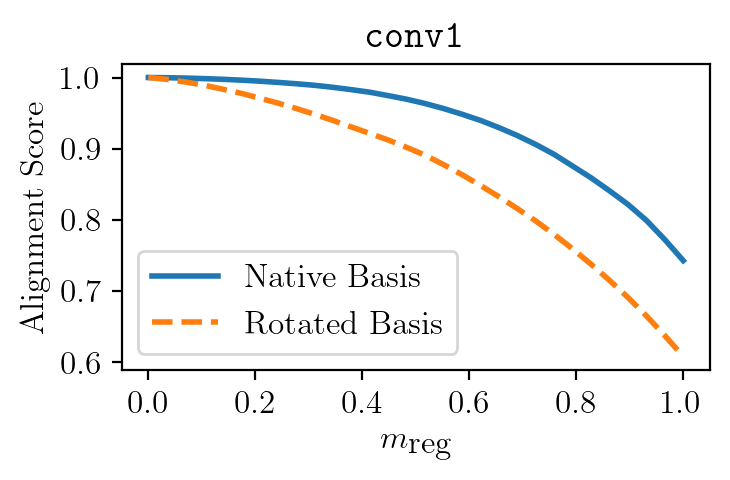

In [9]:
native_scores = [result_dict[m]['native'] for m in mreg]
rotated_scores = [result_dict[m]['rotated'] for m in mreg]

plt.figure(figsize=(3*1.25, 2*1.25))
plt.plot(mreg, native_scores, linestyle='-', linewidth=2., label='Native Basis')
plt.plot(mreg, rotated_scores, linestyle='--', linewidth=2., label='Rotated Basis')
plt.xlabel(r"$m_{\textrm{reg}}$", fontsize=12)
plt.ylabel("Alignment Score", fontsize=12)
plt.title(r"\texttt{conv1}", fontsize=14)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# repeat for all layers

In [14]:
def load_activations(base_path: str, layer_name: str):
    z1 = torch.load(f'{base_path}/seed_1/{layer_name}.pt')
    z2 = torch.load(f'{base_path}/seed_2/{layer_name}.pt')

    return z1, z2

In [15]:
def align_activations(base_path: str, 
                      all_layers: List[str],
                      num_points: int,
                      cost_type: Optional[str]='cosine'):
    mreg = np.linspace(0, 1, num_points) # number of mass regularization parameters to use 
    
    result_dict = {l: {m: {'native': None, 
                           'rotated': None} for m in mreg} 
                   for l in all_layers}

    for l in tqdm(result_dict.keys(), position=0, leave=True):
        print(f'layer: {l}')
        z1, z2 = load_activations(base_path=base_path, layer_name=l)
        rotation_matrix = random_rotation_matrix(dim=z1.shape[-1])
        for m in tqdm(result_dict[l].keys(), position=0, leave=True):
            # compute alignment in native axis
            unsm = UnbalancedSoftMatch(mass_reg=m, cost_type=cost_type)
            native_score = np.mean(np.array(unsm.fit_kfold_score(z1, z2)))
            result_dict[l][m]['native'] = native_score
            
            # compute alignment in rotated axis
            rotated_score = np.mean(np.array(unsm.fit_kfold_score(z1 @ rotation_matrix, z2)))
            result_dict[l][m]['rotated'] = rotated_score

    return result_dict

In [12]:
all_layers_results = align_activations(base_path='/scratch/chkapoor-test/resnet18_activations_in1k/',
                               all_layers=all_layers, num_points=30)

  0%|                                                                                                                                                                                                                  | 0/17 [00:00<?, ?it/s]

layer: conv1


  6%|███████████▊                                                                                                                                                                                             | 1/17 [01:55<30:43, 115.23s/it]

layer: layer1.0.conv1


 12%|███████████████████████▋                                                                                                                                                                                 | 2/17 [03:43<27:49, 111.28s/it]

...

 88%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                       | 15/17 [56:19<11:28, 344.09s/it]

layer: layer4.1.conv1


 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎           | 16/17 [1:03:00<06:01, 361.21s/it]

layer: layer4.1.conv2


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [1:10:20<00:00, 248.26s/it]


In [13]:
mreg = np.linspace(0, 1, 30)

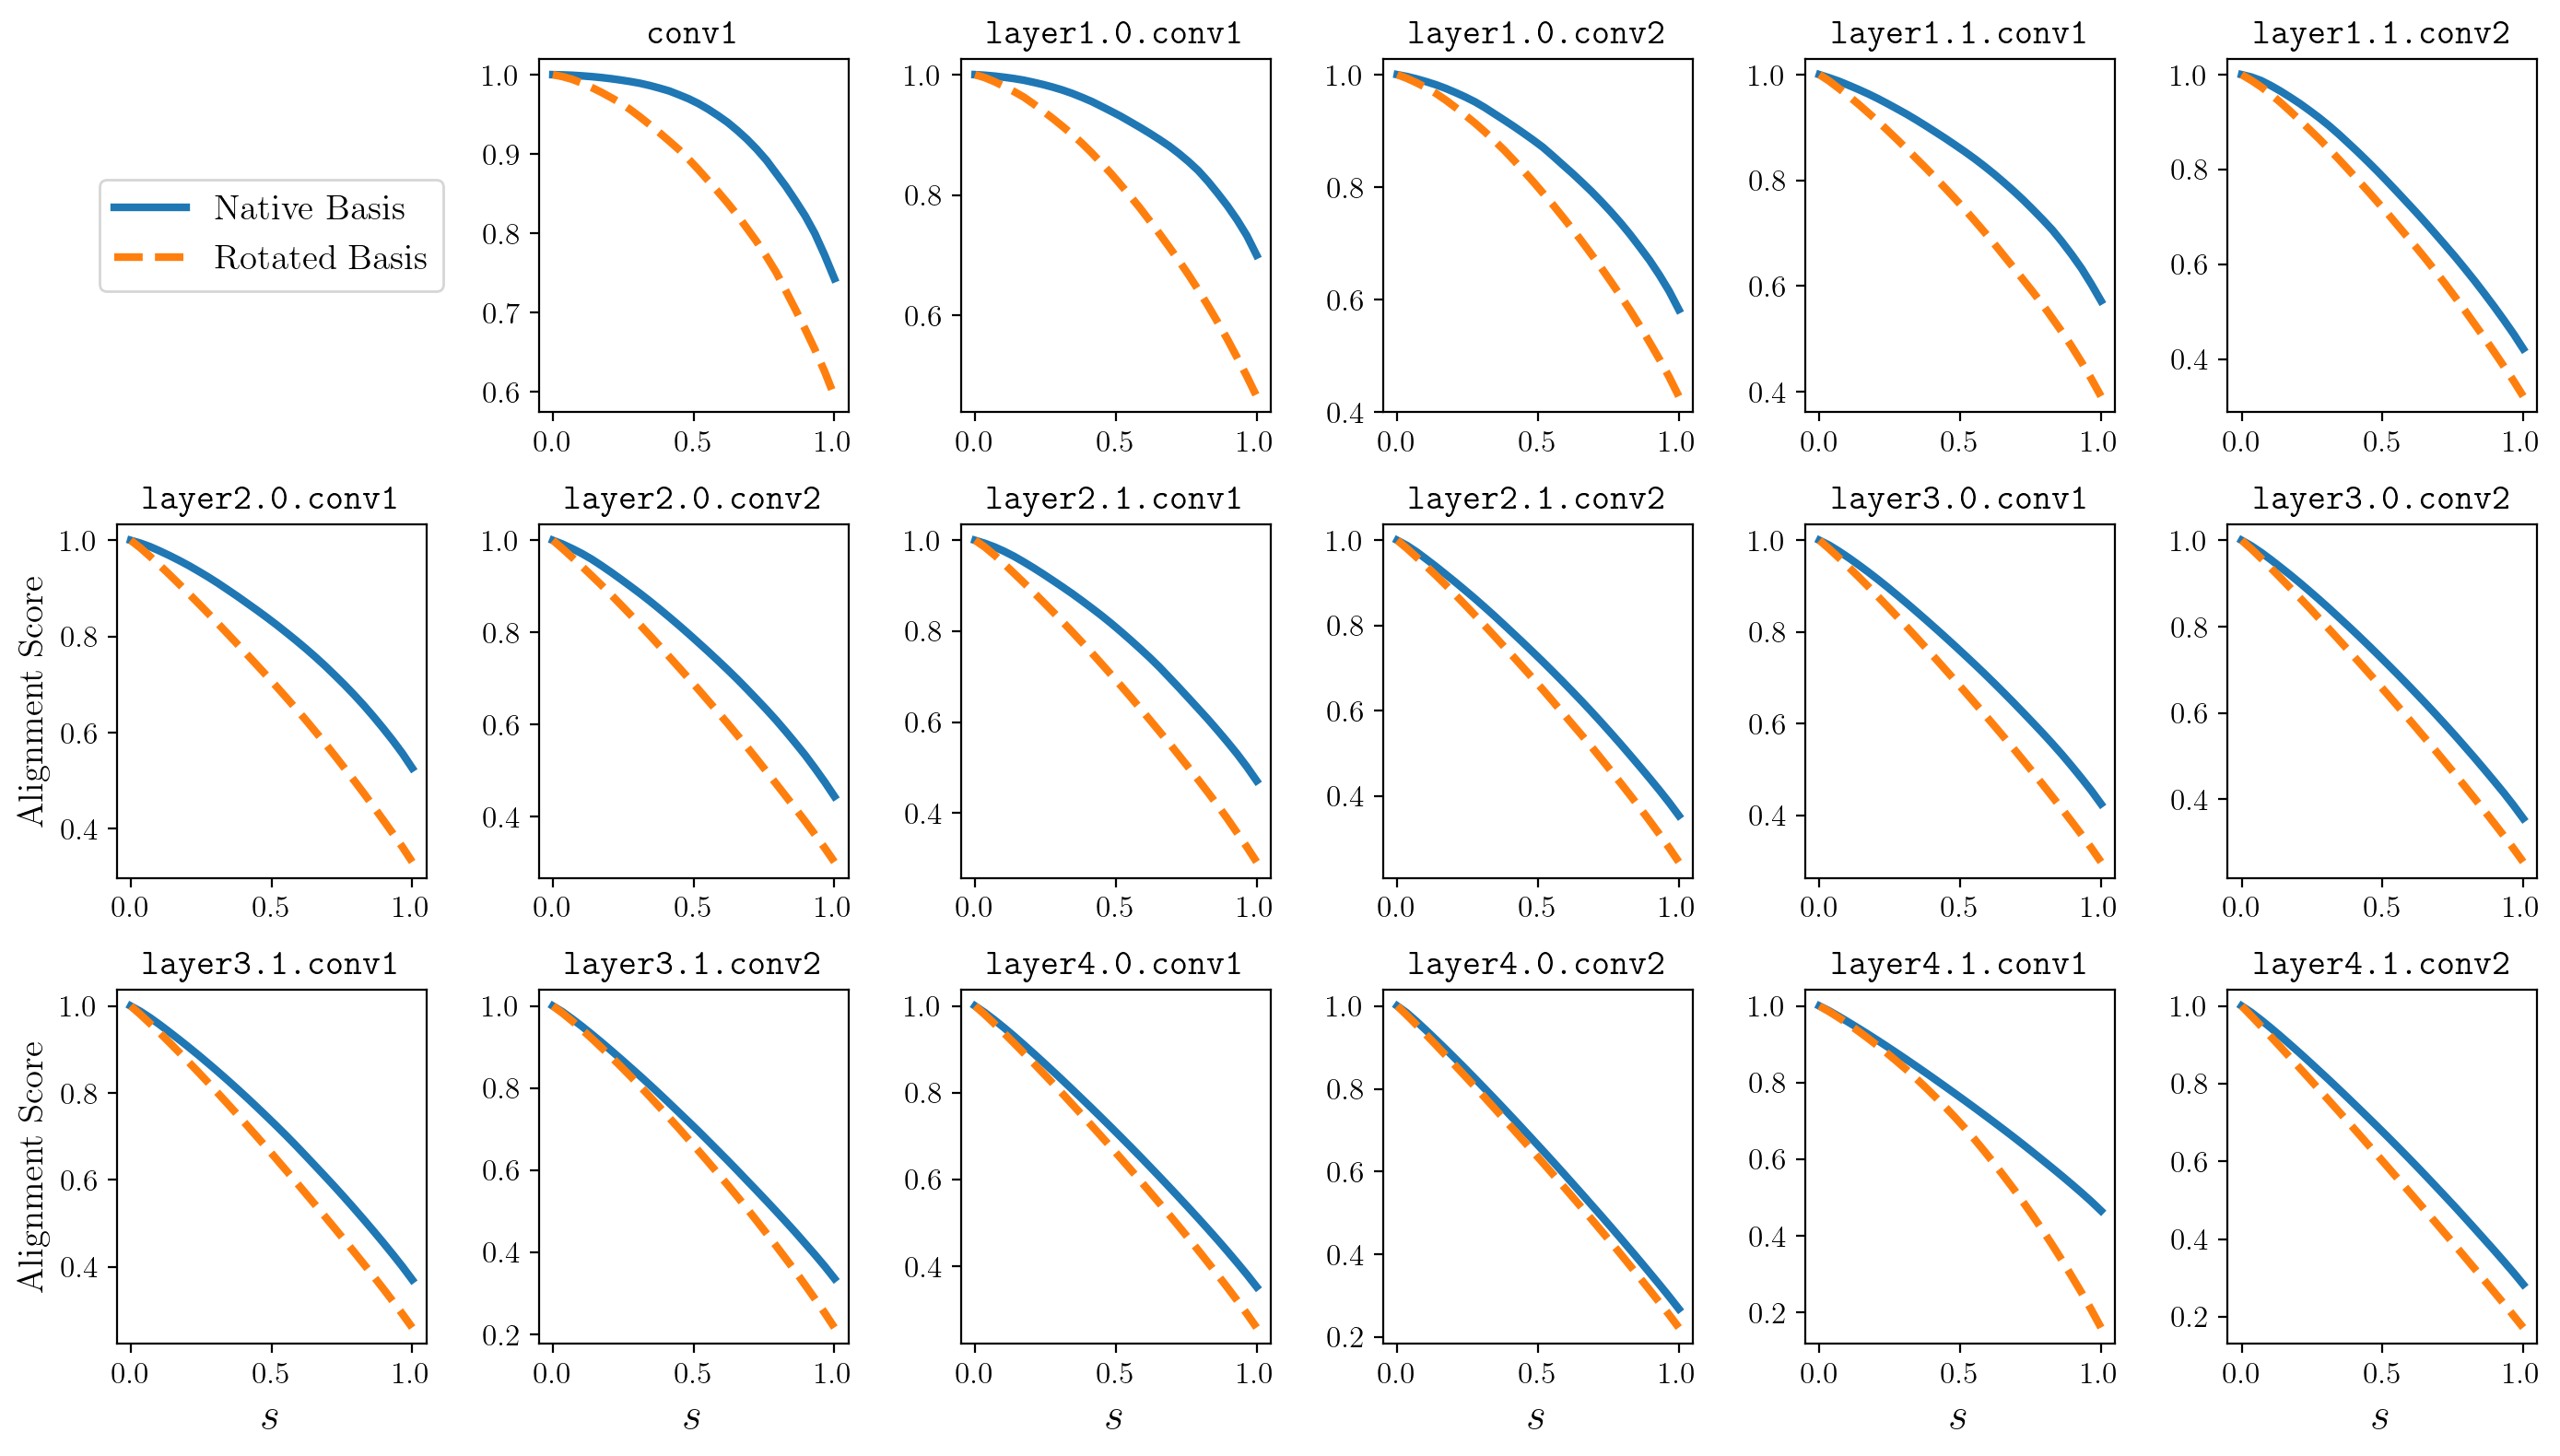

In [16]:
ncols = 6
nrows = 3

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(8*1.75, 8))
axes = axes.flatten()
# we want to put the legend in the top-left corner
ax0 = axes[0]
ax0.axis('off') 
layers = list(all_layers_results.keys())  
mreg = list(next(iter(all_layers_results.values())).keys())  
num_layers = len(layers)

for idx, layer in enumerate(layers):
    ax = axes[idx+1] # offset by 1 to fit legend
    ax.tick_params(axis='both', which='major', labelsize=12)
    native_scores = [all_layers_results[layer][m]['native'] for m in mreg]
    rotated_scores = [all_layers_results[layer][m]['rotated'] for m in mreg]

    ax.plot(mreg, native_scores, linestyle='-', linewidth=3., label='Native Basis')
    ax.plot(mreg, rotated_scores, linestyle='--', linewidth=3., label='Rotated Basis')
    ax.set_title(r"\texttt{" + layer + "}", fontsize=14)

    if (idx+1) % ncols == 0:
        ax.set_ylabel("Alignment Score", fontsize=14)
    if (idx+1) >= (nrows - 1) * ncols:
        #ax.set_xlabel(r"$m_{\textrm{reg}}$", fontsize=14)
        ax.set_xlabel(r"$s$", fontsize=17)

# after plotting, grab the real handles & labels from axes[1]
handles, labels = axes[1].get_legend_handles_labels()
ax0.legend(handles, labels, loc='center', fontsize=14)

# turn off any leftover cells
for ax in axes[num_layers + 1:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('./paper-figures/dnn/privileged_axes_resnet18.png', dpi=300)
plt.show()

# plot a subset

In [17]:
layers_to_plot = [all_layers[0], 
                  all_layers[len(all_layers)//2], 
                  all_layers[-1]]

In [18]:
all_layers_results = align_activations(base_path='/scratch/chkapoor-test/resnet18_activations_in1k/',
                               all_layers=layers_to_plot, num_points=30)

  0%|                                                                                                                                                                                                                   | 0/3 [00:00<?, ?it/s]

layer: conv1


 33%|███████████████████████████████████████████████████████████████████▎                                                                                                                                      | 1/3 [02:31<05:02, 151.32s/it]

layer: layer2.1.conv2


 67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 2/3 [05:06<02:33, 153.69s/it]

layer: layer4.1.conv2


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [12:03<00:00, 241.00s/it]


In [19]:
mreg = np.linspace(0, 1, 30)

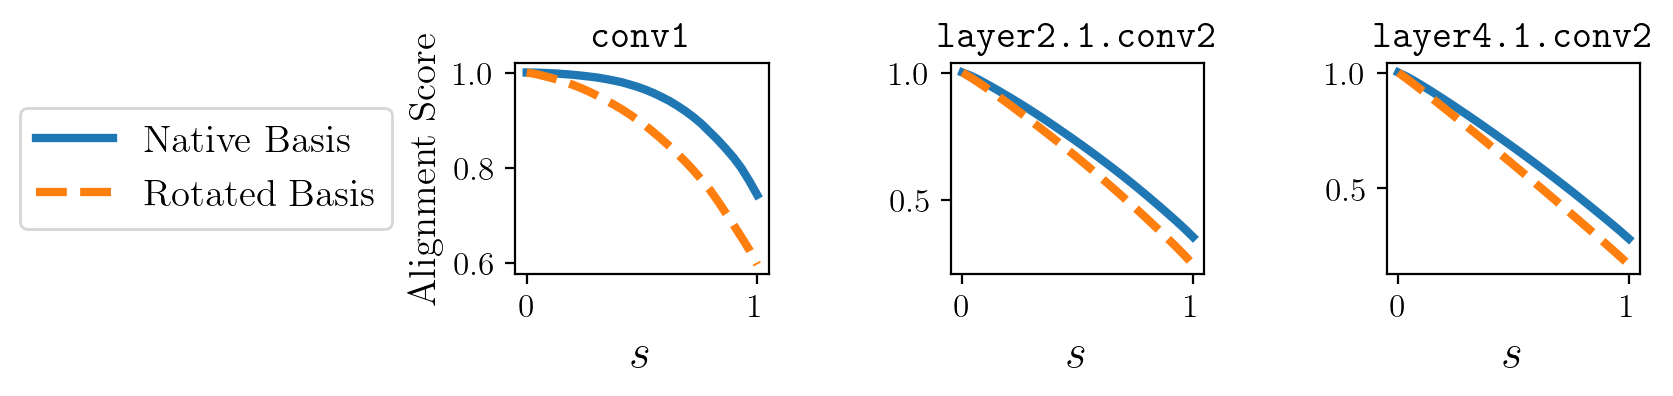

In [20]:
ncols = 4; nrows=1
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(10/1.2, 2.5/1.2))

axes = axes.flatten()
ax0 = axes[0]
ax0.axis('off') 
layers = list(all_layers_results.keys())  
mreg = list(next(iter(all_layers_results.values())).keys())  
num_layers = len(layers)

for idx, layer in enumerate(layers):
    ax = axes[idx+1] # offset by 1 to fit legend
    ax.tick_params(axis='both', which='major', labelsize=12)
    native_scores = [all_layers_results[layer][m]['native'] for m in mreg]
    rotated_scores = [all_layers_results[layer][m]['rotated'] for m in mreg]

    ax.plot(mreg, native_scores, linestyle='-', linewidth=3., label='Native Basis')
    ax.plot(mreg, rotated_scores, linestyle='--', linewidth=3., label='Rotated Basis')
    ax.set_title(r"\texttt{" + layer + "}", fontsize=14)
    #ax.set_xlabel(r"$m_{\textrm{reg}}$", fontsize=14)
    ax.set_xlabel(r"$s$", fontsize=17)
    if idx == 0:
        ax.set_ylabel("Alignment Score", fontsize=14)

    #if (idx+1) % cols == 0:
    #    ax.set_ylabel("Alignment Score", fontsize=14)
    #if (idx+1) >= (rows - 1) * cols:
    #    

# after plotting, grab the real handles & labels from axes[1]
handles, labels = axes[1].get_legend_handles_labels()
ax0.legend(handles, labels, loc='center', fontsize=14)

# turn off any leftover cells
for ax in axes[num_layers + 1:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('./paper-figures/dnn/privileged_axes_resnet18_subset.png', dpi=300)
plt.show()

# use euclidean cost

In [34]:
result_dict = {m: {'native': None, 
                   'rotated': None} for m in mreg}

for m in tqdm(result_dict.keys()):
    # compute alignment in native axis
    unsm = UnbalancedSoftMatch(mass_reg=m, cost_type='euclidean')
    native_score = np.mean(np.array(unsm.fit_kfold_score(z1, z2)))
    result_dict[m]['native'] = native_score
    
    # compute alignment in rotated axis
    rotated_score = np.mean(np.array(unsm.fit_kfold_score(z1 @ rotation_matrix, z2)))
    result_dict[m]['rotated'] = rotated_score

 10%|████████████████████▏                                                                                                                                                                                     | 3/30 [00:09<01:21,  3.03s/it]


KeyboardInterrupt: 

In [16]:
layers_to_plot = [all_layers[0], 
                  all_layers[len(all_layers)//2], 
                  all_layers[-1]]

In [17]:
all_layers_results_euclidean = align_activations(base_path='/scratch/chkapoor-test/resnet18_activations_in1k/',
                               all_layers=layers_to_plot, num_points=30, cost_type='euclidean')

  0%|                                                                                                                                                                                                                   | 0/3 [00:00<?, ?it/s]

layer: conv1


 33%|███████████████████████████████████████████████████████████████████▎                                                                                                                                      | 1/3 [03:30<07:00, 210.08s/it]

layer: layer2.1.conv2


 67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                                   | 2/3 [07:19<03:41, 221.50s/it]

layer: layer4.1.conv2


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [15:57<00:00, 319.19s/it]


In [18]:
all_layers_results_euclidean

{'conv1': {np.float64(0.0): {'native': np.float64(0.0),
   'rotated': np.float64(0.0)},
  np.float64(0.034482758620689655): {'native': np.float64(9.387154006958008),
   'rotated': np.float64(123.41772003173828)},
  np.float64(0.06896551724137931): {'native': np.float64(35.85520935058594),
   'rotated': np.float64(264.74493408203125)},
  np.float64(0.10344827586206896): {'native': np.float64(69.74091949462891),
   'rotated': np.float64(422.9573547363281)},
  np.float64(0.13793103448275862): {'native': np.float64(109.8515625),
   'rotated': np.float64(592.1506591796875)},
  np.float64(0.1724137931034483): {'native': np.float64(157.42949523925782),
   'rotated': np.float64(768.9513427734375)},
  np.float64(0.20689655172413793): {'native': np.float64(213.11345825195312),
   'rotated': np.float64(963.5729370117188)},
  np.float64(0.24137931034482757): {'native': np.float64(280.548876953125),
   'rotated': np.float64(1175.981396484375)},
  np.float64(0.27586206896551724): {'native': np.float

In [19]:
mreg = np.linspace(0, 1, 30)

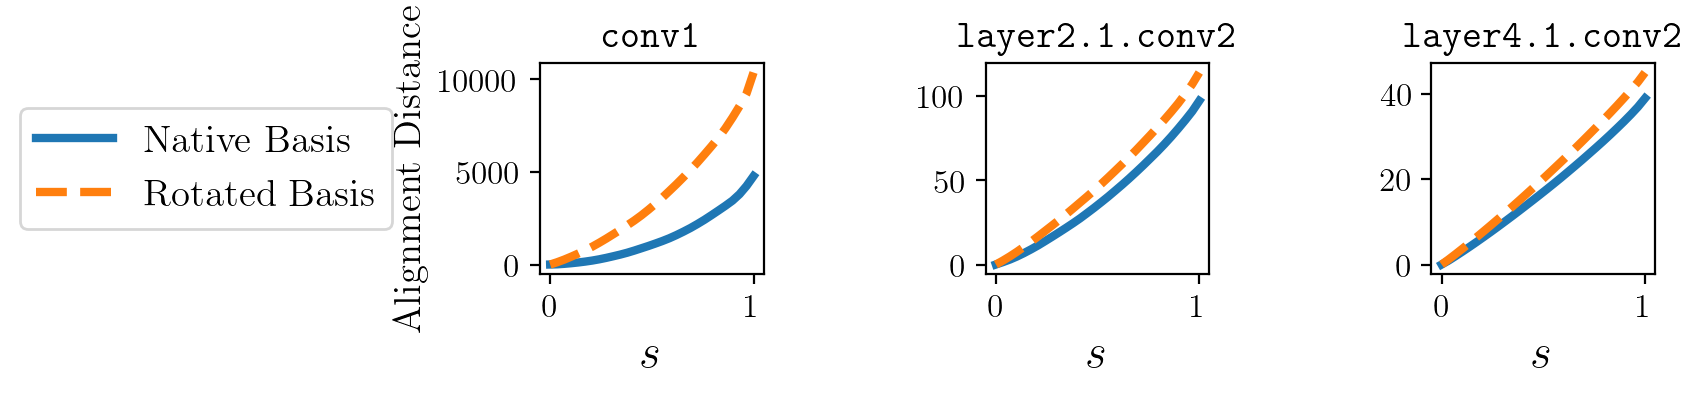

In [22]:
ncols = 4; nrows=1
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(10/1.2, 2.5/1.2))

axes = axes.flatten()
ax0 = axes[0]
ax0.axis('off') 
layers = list(all_layers_results_euclidean.keys())  
mreg = list(next(iter(all_layers_results_euclidean.values())).keys())  
num_layers = len(layers)

for idx, layer in enumerate(layers):
    ax = axes[idx+1] # offset by 1 to fit legend
    ax.tick_params(axis='both', which='major', labelsize=12)
    native_scores = [all_layers_results_euclidean[layer][m]['native'] for m in mreg]
    rotated_scores = [all_layers_results_euclidean[layer][m]['rotated'] for m in mreg]

    ax.plot(mreg, native_scores, linestyle='-', linewidth=3., label='Native Basis')
    ax.plot(mreg, rotated_scores, linestyle='--', linewidth=3., label='Rotated Basis')
    ax.set_title(r"\texttt{" + layer + "}", fontsize=14)
    #ax.set_xlabel(r"$m_{\textrm{reg}}$", fontsize=14)
    ax.set_xlabel(r"$s$", fontsize=17)
    if idx == 0:
        ax.set_ylabel("Alignment Distance", fontsize=14)

    #if (idx+1) % cols == 0:
    #    ax.set_ylabel("Alignment Score", fontsize=14)
    #if (idx+1) >= (rows - 1) * cols:
    #    

# after plotting, grab the real handles & labels from axes[1]
handles, labels = axes[1].get_legend_handles_labels()
ax0.legend(handles, labels, loc='center', fontsize=14)

# turn off any leftover cells
for ax in axes[num_layers + 1:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('./paper-figures/dnn/privileged_axes_resnet18_subset_euclidean.png', dpi=300)
plt.show()